In [21]:
!unzip lung_cancer_dataset.zip -d /content/

Archive:  lung_cancer_dataset.zip
replace /content/lung_cancer_dataset/Test/000001_03_01_088.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/lung_cancer_dataset/Test/000001_03_01_088.png  
replace /content/lung_cancer_dataset/Test/000017_02_01_016.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/lung_cancer_dataset/Test/000017_02_01_016.png  
replace /content/lung_cancer_dataset/Test/000019_01_01_021.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 
error:  invalid response [{ENTER}]
replace /content/lung_cancer_dataset/Test/000019_01_01_021.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

error:  invalid response [{ENTER}]
replace /content/lung_cancer_dataset/Test/000019_01_01_021.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [{ENTER}]
replace /content/lung_cancer_dataset/Test/000019_01_01_021.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

error:  invalid response [{ENTER}]
replace /content/lung_cancer_dataset/Test/000019_01_01_021.png? [

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms,models
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset
import os
from PIL import Image
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F
import matplotlib.pyplot as plt



Classes found: ['Bengin cases', 'Malignant cases', 'Normal cases']
Bengin cases: 121 images
Malignant cases: 561 images
Normal cases: 416 images


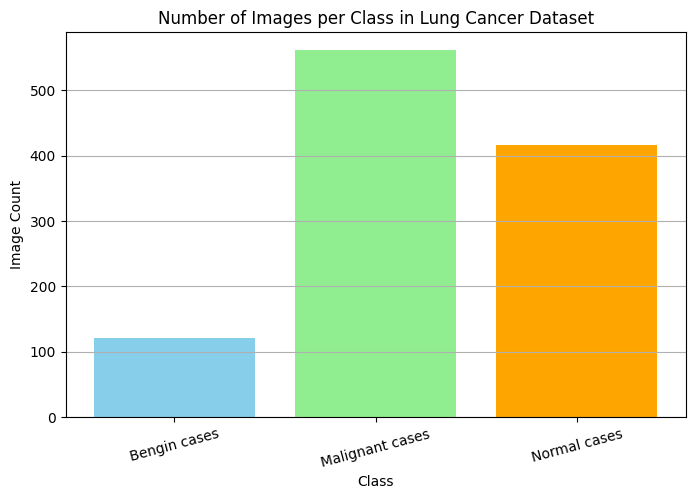

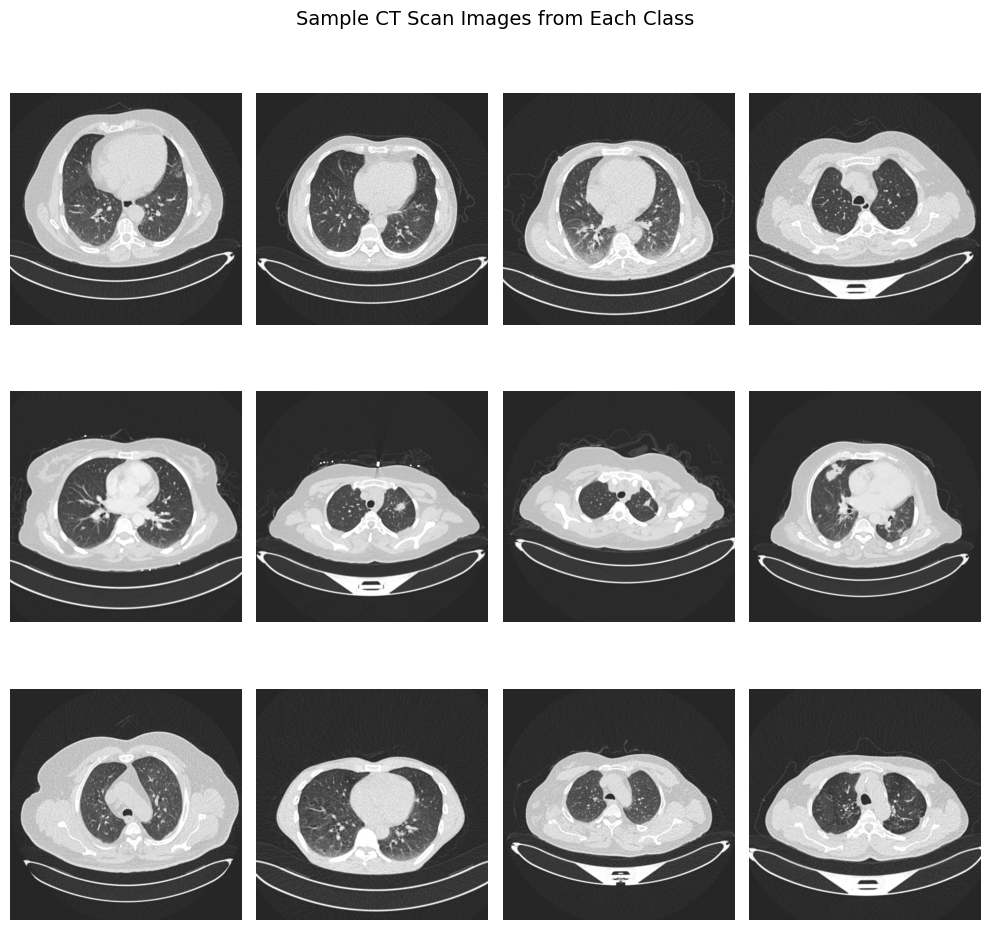

Average Width: 522.3 px
Average Height: 509.0 px


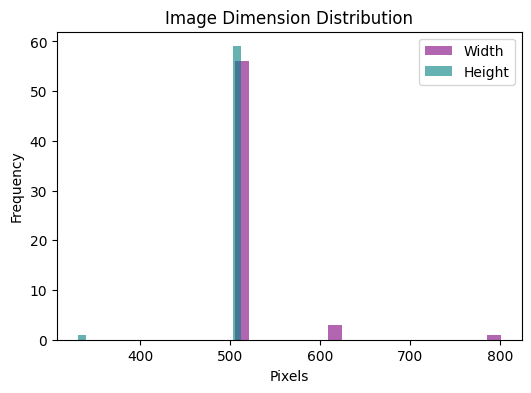

In [29]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# ====================================================
# 1️⃣ Define dataset path
# ====================================================
dataset_path = "/content/lung_cancer_dataset/train"

# Check classes in dataset
class_names = sorted([
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
])

print("Classes found:", class_names)

# ====================================================
# 2️⃣ Count number of images per class
# ====================================================
image_counts = [
    len([f for f in os.listdir(os.path.join(dataset_path, cls))
         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    for cls in class_names
]

for cls, count in zip(class_names, image_counts):
    print(f"{cls}: {count} images")

# ====================================================
# 3️⃣ Plot class distribution
# ====================================================
plt.figure(figsize=(8,5))
plt.bar(class_names, image_counts, color=['skyblue', 'lightgreen', 'orange', 'salmon'])
plt.title("Number of Images per Class in Lung Cancer Dataset")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

# ====================================================
# 4️⃣ Display sample images from each class
# ====================================================
fig, axes = plt.subplots(len(class_names), 4, figsize=(10, 10))
fig.suptitle("Sample CT Scan Images from Each Class", fontsize=14)

for i, cls in enumerate(class_names):
    class_dir = os.path.join(dataset_path, cls)
    sample_imgs = random.sample(os.listdir(class_dir), 4)

    for j, img_name in enumerate(sample_imgs):
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=10, rotation=0, labelpad=45)

plt.tight_layout()
plt.show()

# ====================================================
# 5️⃣ (Optional) Image size analysis
# ====================================================
heights, widths = [], []

for cls in class_names:
    class_dir = os.path.join(dataset_path, cls)
    sample_imgs = random.sample(os.listdir(class_dir), min(20, len(os.listdir(class_dir))))
    for img_name in sample_imgs:
        img_path = os.path.join(class_dir, img_name)
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

print(f"Average Width: {np.mean(widths):.1f} px")
print(f"Average Height: {np.mean(heights):.1f} px")

plt.figure(figsize=(6,4))
plt.hist(widths, bins=20, color='purple', alpha=0.6, label='Width')
plt.hist(heights, bins=20, color='teal', alpha=0.6, label='Height')
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.title("Image Dimension Distribution")
plt.legend()
plt.show()


In [30]:
torch.manual_seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")

Using device: cuda


In [31]:
class CustomDataset(Dataset):
  def __init__(self, root_dir, transform=None):
      """
      root_dir: path to dataset folder (with subfolders for each class)
      transform: torchvision transforms to apply
      """
      self.transform = transform
      self.features = []  # store file paths
      self.labels = []    # integer labels
      self.class_to_idx = {}

      # scan folders
      for idx, class_name in enumerate(sorted(os.listdir(root_dir))):
          class_path = os.path.join(root_dir, class_name)
          if os.path.isdir(class_path):
              self.class_to_idx[class_name] = idx
              for fname in os.listdir(class_path):
                  if fname.endswith(('.png', '.jpg', '.jpeg')):
                      self.features.append(os.path.join(class_path, fname))
                      self.labels.append(idx)

  def __len__(self):
      return len(self.features)

  def __getitem__(self, index):
      # Load image
      image = Image.open(self.features[index]).convert("RGB")  # ensure 3 channels

      # Apply transforms
      if self.transform:
          image = self.transform(image)

      # Return image tensor and label
      return image, torch.tensor(self.labels[index], dtype=torch.long)

Image Transformation according to requirements of VGG16!

In [32]:
train_transform = transforms.Compose([
      transforms.Grayscale(num_output_channels=3),           # convert 1 channel -> 3 channel
      transforms.Resize(256),
      transforms.CenterCrop(224),
      transforms.RandomHorizontalFlip(),                     # flip sometimes
      transforms.RandomRotation(10),                         # rotate a little
      transforms.ColorJitter(brightness=0.1, contrast=0.1),  # small changes
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# Test transforms without augmentation
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

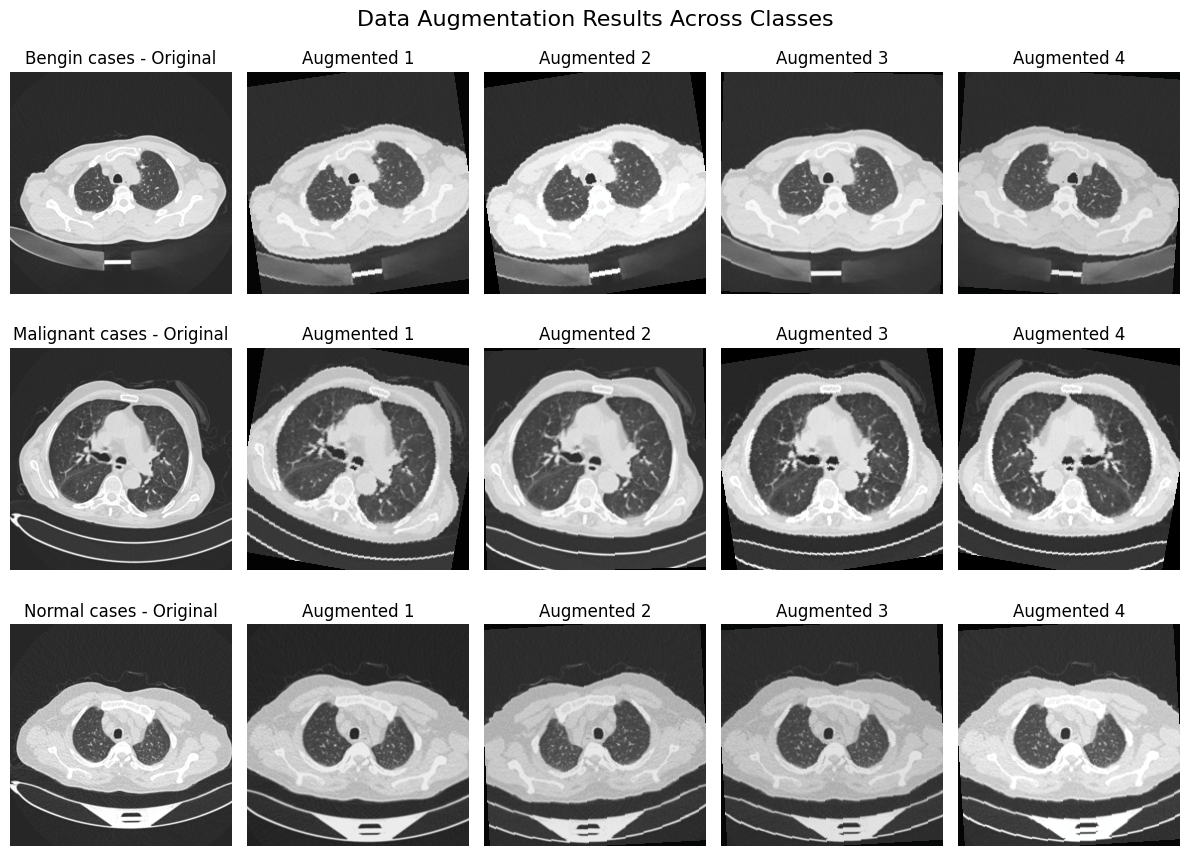

In [33]:
import matplotlib.pyplot as plt
import random
from PIL import Image

# ====================================================
# Data Augmentation Transform (already defined for training)
# ====================================================
augment_transform = train_transform  # reuse your train_transform

# Number of augmented samples to show per class
num_aug_samples = 4

# Setup plot: rows = number of classes, cols = original + augmented images
fig, axes = plt.subplots(len(class_names), num_aug_samples + 1, figsize=(12, 3 * len(class_names)))
fig.suptitle("Data Augmentation Results Across Classes", fontsize=16)

for i, cls in enumerate(class_names):
    class_dir = os.path.join(dataset_path, cls)
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Pick a random image as base
    img_name = random.choice(images)
    img_path = os.path.join(class_dir, img_name)
    img = Image.open(img_path).convert("RGB")

    # Plot original image in the first column
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"{cls} - Original")
    axes[i, 0].axis('off')

    # Plot augmented versions
    for j in range(1, num_aug_samples + 1):
        aug_img = augment_transform(img)  # apply augmentation
        # Convert tensor to numpy image for plotting
        img_np = aug_img.numpy().transpose((1, 2, 0))
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # unnormalize
        img_np = np.clip(img_np, 0, 1)

        axes[i, j].imshow(img_np)
        axes[i, j].set_title(f"Augmented {j}")
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()


In [34]:
# Load dataset from Train folder
# -----------------------------
dataset = CustomDataset(root_dir="/content/lung_cancer_dataset/train",
                        transform=None)

print("Class to index mapping:", dataset.class_to_idx)
print("Total images:", len(dataset))

Class to index mapping: {'Bengin cases': 0, 'Malignant cases': 1, 'Normal cases': 2}
Total images: 1098


In [35]:
# Split dataset (80% train, 20% test)
# -----------------------------
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Apply train transform to train_dataset
train_dataset.dataset.transform = train_transform

# Apply test transform to test_dataset
test_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 878
Test samples: 220


In [36]:
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vgg16 = models.vgg16(pretrained=True)

# Freeze feature extraction layers
for param in vgg16.features.parameters():
    param.requires_grad = False

# Replace classifier
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(dataset.class_to_idx))  # number of classes
)

vgg16 = vgg16.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 85.0MB/s]


In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=1e-4)  # only classifier params
epochs = 10

In [38]:
epoch_losses = [] #store loss at each epoch
epoch_accuracies = [] # store accuracy at each epoch


for epoch in range(epochs):
    vgg16.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg16(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Calculate number of correct predictions in this batch
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_loss)

    accuracy = 100 * correct / total
    epoch_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Accuracy = {accuracy:.2f}%")


Epoch 1, Loss: 0.5244, Accuracy = 79.61%
Epoch 2, Loss: 0.2513, Accuracy = 90.09%
Epoch 3, Loss: 0.1471, Accuracy = 94.65%
Epoch 4, Loss: 0.0891, Accuracy = 96.47%
Epoch 5, Loss: 0.0460, Accuracy = 98.97%
Epoch 6, Loss: 0.0355, Accuracy = 99.09%
Epoch 7, Loss: 0.0161, Accuracy = 99.89%
Epoch 8, Loss: 0.0146, Accuracy = 99.66%
Epoch 9, Loss: 0.0117, Accuracy = 99.77%
Epoch 10, Loss: 0.0089, Accuracy = 99.66%


In [39]:
#test accuracy
vgg16.eval()
correct = 0
total = 0

all_labels = [] #for auc
all_probs = [] #for auc

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg16(images)

        probs = F.softmax(outputs, dim=1)  # convert logits to probabilities/AUC
        all_labels.extend(labels.cpu().numpy().tolist())  # make sure it's a list of ints/AUC
        all_probs.extend(probs.cpu().numpy())   #AUC

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"✅ Test Accuracy: {accuracy:.2f}%")


✅ Test Accuracy: 99.55%


In [40]:
import numpy as np
from sklearn.preprocessing import label_binarize

# Number of classes
num_classes = len(dataset.class_to_idx)

# Convert labels to one-hot encoding
all_labels_onehot = label_binarize(all_labels, classes=range(num_classes))

# Compute AUC
auc = roc_auc_score(all_labels_onehot, np.array(all_probs), average='macro', multi_class='ovr')
print(f"✅ Test AUC (macro, one-vs-rest): {100*auc:.4f}")


✅ Test AUC (macro, one-vs-rest): 99.9884


Trainig Loss VS Epochs

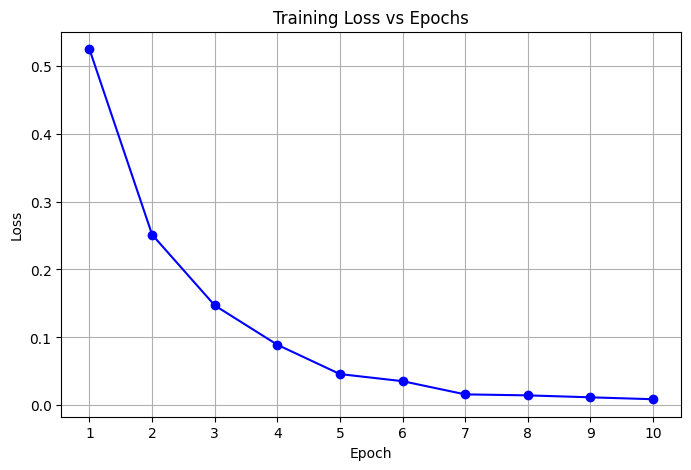

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), epoch_losses, marker='o', color='blue')
plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, epochs+1))
plt.grid(True)
plt.show()


number of epochs vs accuracy

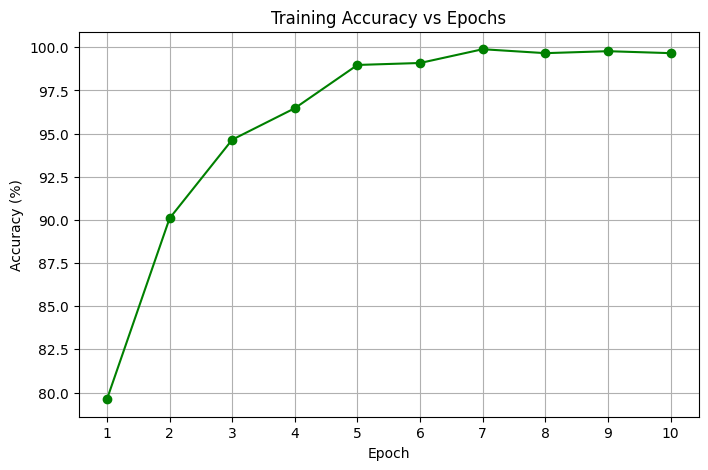

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), epoch_accuracies, marker='o', color='green')
plt.title("Training Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(range(1, epochs+1))
plt.grid(True)
plt.show()


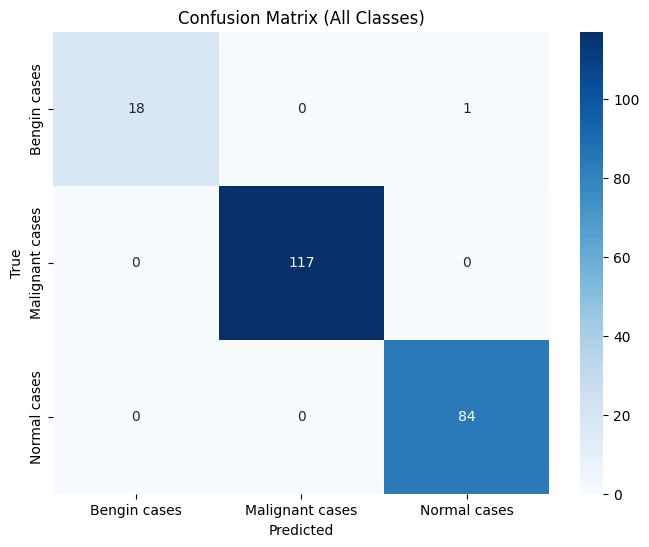

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

# Collect predictions
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg16(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Class mapping
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
class_names = list(idx_to_class.values())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (All Classes)")
plt.show()


In [44]:
# Optional: class-wise accuracy
from sklearn.metrics import classification_report

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg16(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(idx_to_class.values())))



Classification Report:

                 precision    recall  f1-score   support

   Bengin cases       1.00      0.95      0.97        19
Malignant cases       1.00      1.00      1.00       117
   Normal cases       0.99      1.00      0.99        84

       accuracy                           1.00       220
      macro avg       1.00      0.98      0.99       220
   weighted avg       1.00      1.00      1.00       220



Precision-Recall Curves

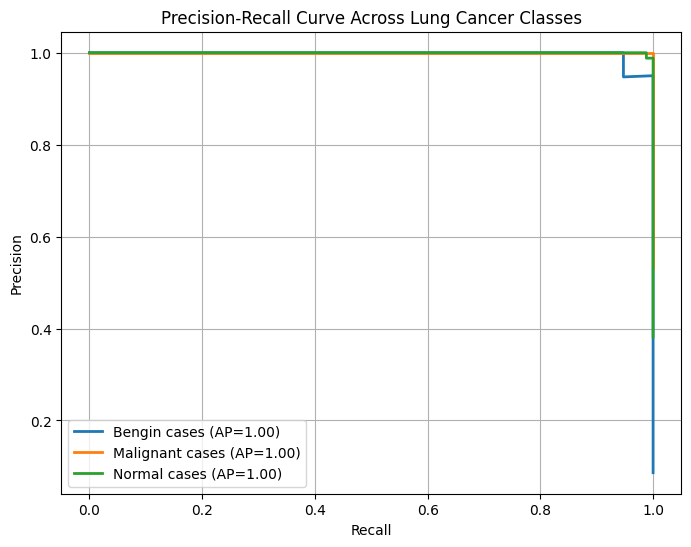

In [45]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Convert labels to one-hot encoding
from sklearn.preprocessing import label_binarize
num_classes = len(dataset.class_to_idx)
all_labels_onehot = label_binarize(all_labels, classes=range(num_classes))
all_probs_array = np.array(all_probs)

# Plot Precision-Recall curves
plt.figure(figsize=(8,6))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(all_labels_onehot[:, i], all_probs_array[:, i])
    avg_precision = average_precision_score(all_labels_onehot[:, i], all_probs_array[:, i])
    plt.plot(recall, precision, lw=2, label=f"{class_names[i]} (AP={avg_precision:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Across Lung Cancer Classes")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


F1-CONFIDENCE CURVE

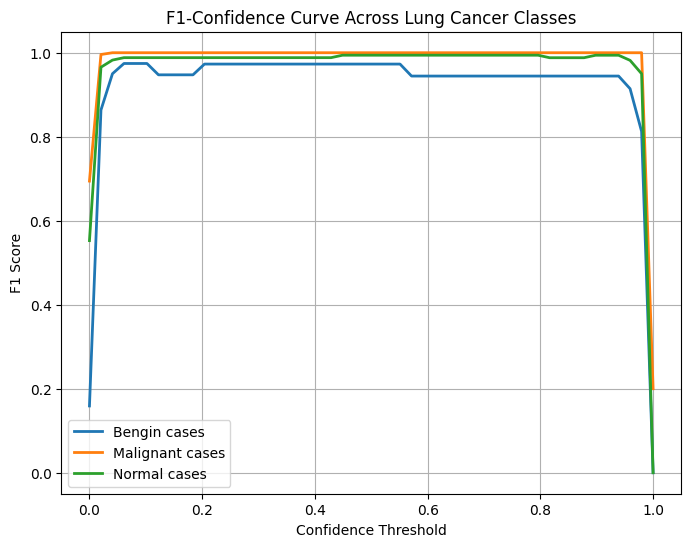

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Ensure all_labels and all_probs are already defined
all_labels_array = np.array(all_labels)  # shape: (num_samples,)
all_probs_array = np.array(all_probs)    # shape: (num_samples, num_classes)

num_classes = len(dataset.class_to_idx)
thresholds = np.linspace(0.0, 1.0, 50)  # confidence thresholds
f1_scores_per_class = {cls: [] for cls in class_names}

for i, cls in enumerate(class_names):
    true_binary = (all_labels_array == i).astype(int)  # one-vs-rest
    class_probs = all_probs_array[:, i]

    for t in thresholds:
        pred_binary = (class_probs >= t).astype(int)
        # Avoid zero division
        if pred_binary.sum() == 0:
            f1 = 0.0
        else:
            f1 = f1_score(true_binary, pred_binary)
        f1_scores_per_class[cls].append(f1)

# Plot F1-confidence curves
plt.figure(figsize=(8,6))
for cls in class_names:
    plt.plot(thresholds, f1_scores_per_class[cls], lw=2, label=cls)

plt.xlabel("Confidence Threshold")
plt.ylabel("F1 Score")
plt.title("F1-Confidence Curve Across Lung Cancer Classes")
plt.legend()
plt.grid(True)
plt.show()


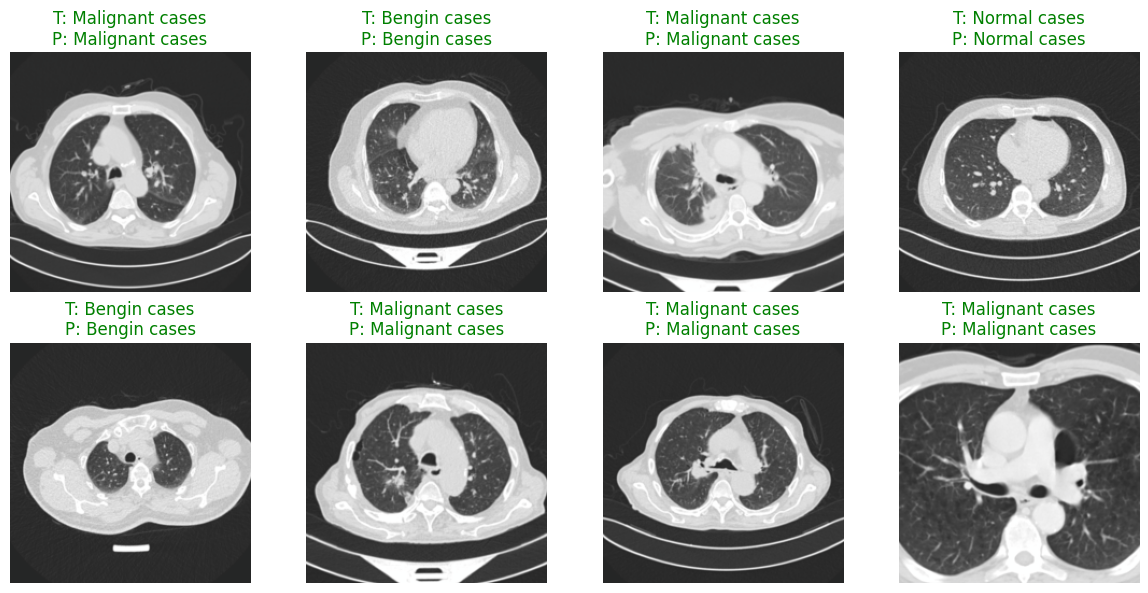

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Switch to evaluation mode
vgg16.eval()

# Fetch a small batch from the test loader
dataiter = iter(test_loader)
images, labels = next(dataiter)

images, labels = images.to(device), labels.to(device)

# Make predictions
with torch.no_grad():
    outputs = vgg16(images)
    _, preds = torch.max(outputs, 1)

# Move tensors to CPU for visualization
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

# Get class name mapping
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

# Helper to unnormalize and convert tensor -> numpy image
def imshow(img, ax):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean  # unnormalize
    img = np.clip(img, 0, 1)
    ax.imshow(img)

# Plot first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    imshow(images[i], ax)
    true_label = idx_to_class[labels[i].item()]
    pred_label = idx_to_class[preds[i].item()]
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"T: {true_label}\nP: {pred_label}", color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()


/tmp/ipython-input-240603372.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = pd.Series(epoch_accuracies, index=pd.date_range(start='2025-01-01', periods=len(epoch_accuracies), freq='M'))


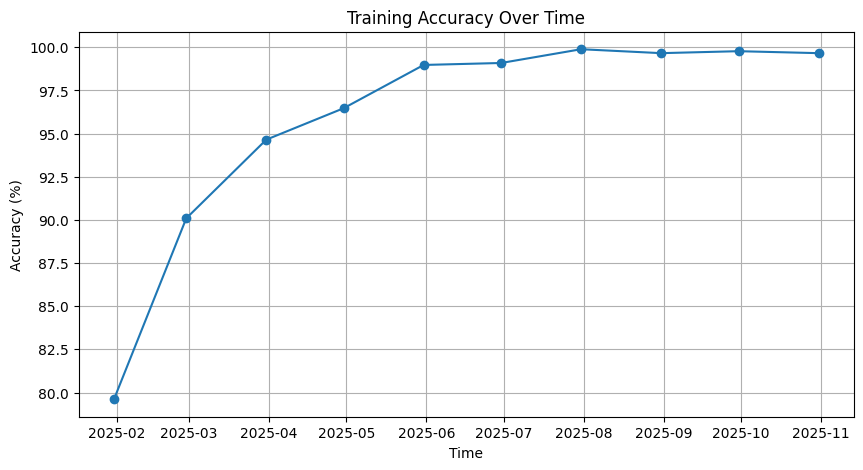

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/tmp/ipython-input-240603372.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_index = pd.date_range(start=data.index[-1] + pd.offsets.MonthEnd(1), periods=forecast_steps, freq='M')


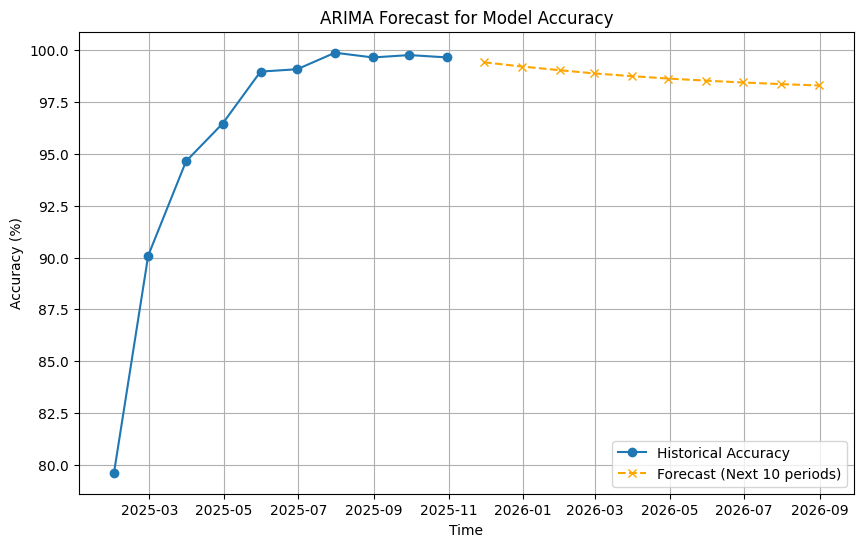

    Period  Forecasted Accuracy (%)
0  2025-11                99.424019
1  2025-12                99.220269
2  2026-01                99.043082
3  2026-02                98.888995
4  2026-03                98.754996
5  2026-04                98.638467
6  2026-05                98.537130
7  2026-06                98.449004
8  2026-07                98.372368
9  2026-08                98.305722


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1️⃣ Prepare the time series
# Convert epoch accuracies into a pandas Series with a datetime index
epochs = np.arange(1, len(epoch_accuracies) + 1)
data = pd.Series(epoch_accuracies, index=pd.date_range(start='2025-01-01', periods=len(epoch_accuracies), freq='M'))

# 2️⃣ Plot the original series
plt.figure(figsize=(10,5))
plt.plot(data.index, data, marker='o')
plt.title("Training Accuracy Over Time")
plt.xlabel("Time")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

# 3️⃣ Fit ARIMA model
# Choose order (p,d,q) — small series, simple ARIMA(1,1,1) usually works
model = ARIMA(data, order=(1,1,1))
model_fit = model.fit()

# 4️⃣ Forecast next 10 "periods" (here, months, but can treat as years for long-term prediction)
forecast_steps = 10
forecast = model_fit.forecast(steps=forecast_steps)

# 5️⃣ Create future date index
future_index = pd.date_range(start=data.index[-1] + pd.offsets.MonthEnd(1), periods=forecast_steps, freq='M')

# 6️⃣ Plot actual + forecast
plt.figure(figsize=(10,6))
plt.plot(data.index, data, label='Historical Accuracy', marker='o')
plt.plot(future_index, forecast, label='Forecast (Next 10 periods)', marker='x', linestyle='--', color='orange')
plt.title("ARIMA Forecast for Model Accuracy")
plt.xlabel("Time")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

# 7️⃣ Display forecast table
forecast_table = pd.DataFrame({
    'Period': future_index.strftime('%Y-%m'),
    'Forecasted Accuracy (%)': forecast.values
})
print(forecast_table)



Analyzing: Training Loss


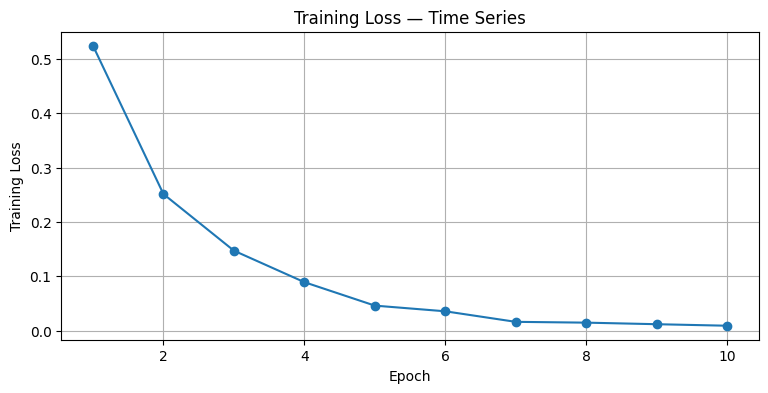

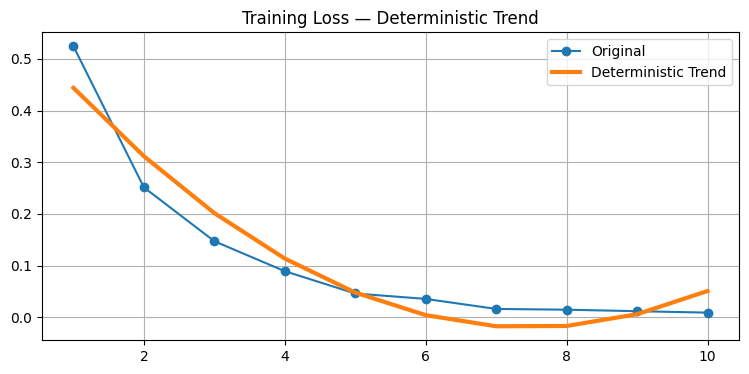

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as s

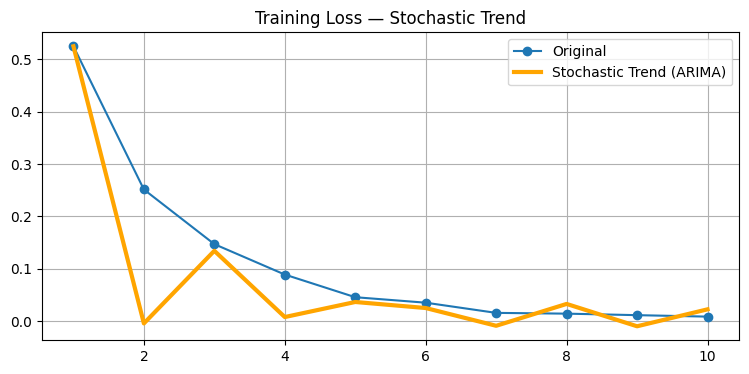

Using Fourier order k = 5 (auto-adjusted)


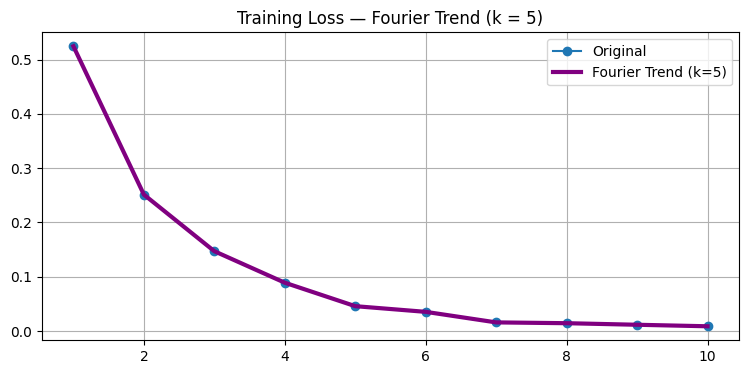

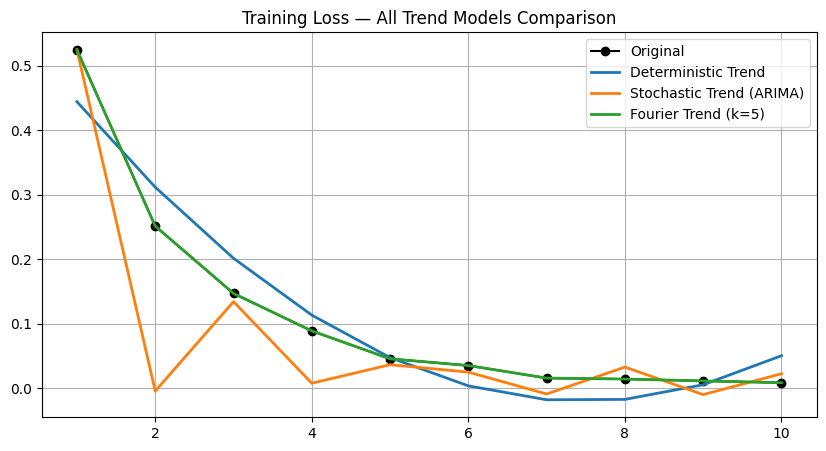


Analyzing: Training Accuracy


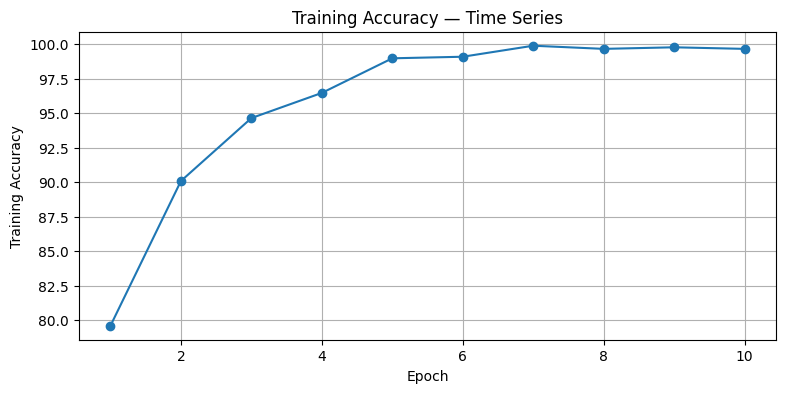

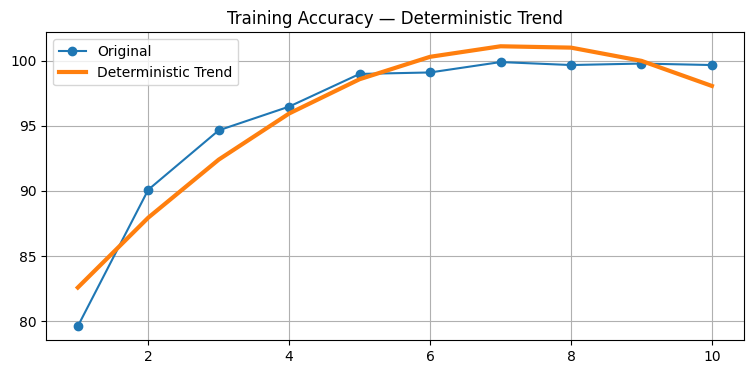

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as s

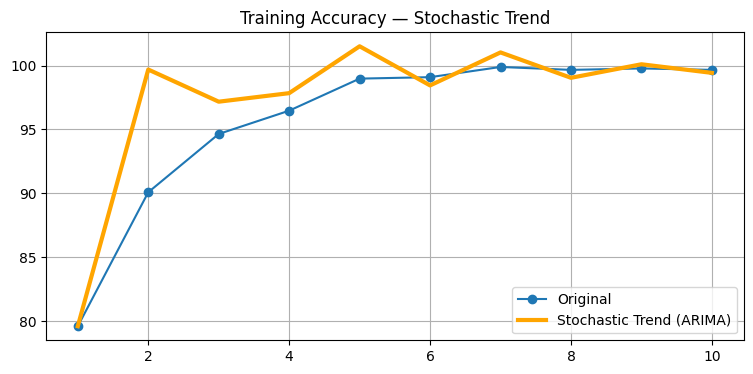

Using Fourier order k = 5 (auto-adjusted)


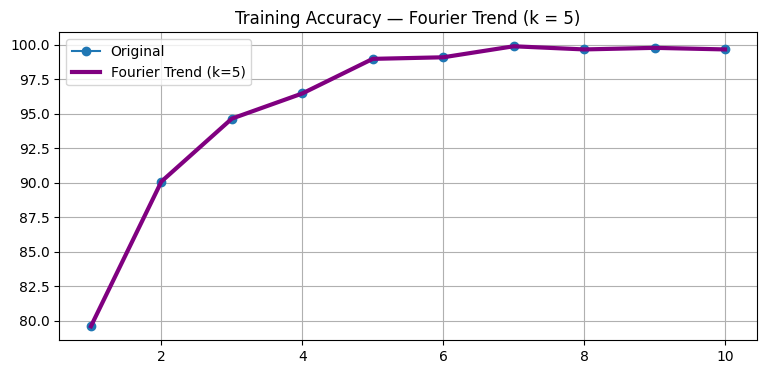

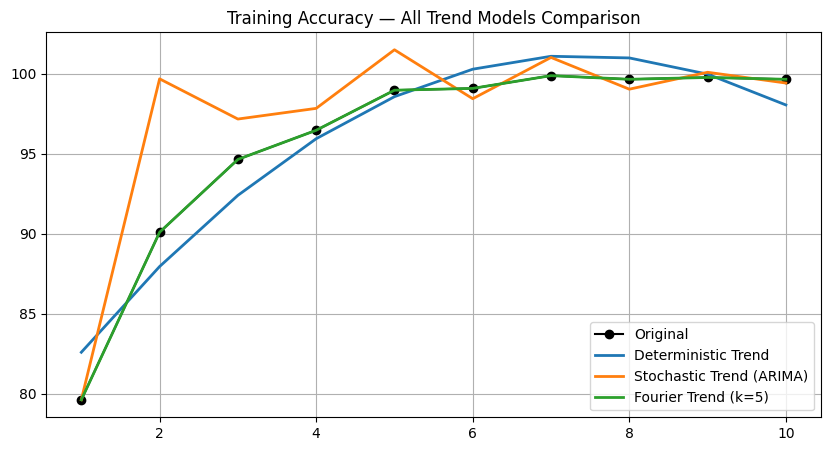

In [58]:
# ============================================
# FULL TREND ANALYSIS PIPELINE (ONE CELL)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.deterministic import DeterministicProcess, Fourier


# --------------------------------------------
# Helper function: Applies all 3 trends to a TS
# --------------------------------------------
def analyze_trends(series, title_name):

    print(f"\n===========================")
    print(f"Analyzing: {title_name}")
    print(f"===========================")

    ts = pd.Series(series, index=np.arange(1, len(series)+1))
    ts.index.name = "Epoch"
    period = len(ts)

    # -------------------------
    # Raw time series
    # -------------------------
    plt.figure(figsize=(9,4))
    plt.plot(ts, marker='o')
    plt.title(f"{title_name} — Time Series")
    plt.xlabel("Epoch")
    plt.ylabel(title_name)
    plt.grid(True)
    plt.show()

    # -------------------------
    # 1️⃣ Deterministic Trend
    # -------------------------
    dp = DeterministicProcess(
        index=ts.index,
        constant=True,
        order=2
    )
    X_det = dp.in_sample()
    model_det = OLS(ts, X_det).fit()
    trend_det = model_det.fittedvalues

    plt.figure(figsize=(9,4))
    plt.plot(ts, label="Original", marker='o')
    plt.plot(trend_det, label="Deterministic Trend", linewidth=3)
    plt.title(f"{title_name} — Deterministic Trend")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------
    # 2️⃣ Stochastic Trend (ARIMA)
    # -------------------------
    model_stoch = ARIMA(ts, order=(1,1,1)).fit()
    trend_stoch = model_stoch.predict(start=1, end=len(ts))

    plt.figure(figsize=(9,4))
    plt.plot(ts, label="Original", marker='o')
    plt.plot(trend_stoch, label="Stochastic Trend (ARIMA)", linewidth=3, color='orange')
    plt.title(f"{title_name} — Stochastic Trend")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------
    # 3️⃣ Fourier Trend (k = 6 but AUTO FIXED)
    # -------------------------

    # Compute valid maximum k
    max_k = period // 2       # bc 2*k <= period
    k = min(6, max_k)

    if k < 1:
        print("⚠ Fourier terms cannot be computed (series too short). Skipping.")
        trend_fourier = None
    else:
        print(f"Using Fourier order k = {k} (auto-adjusted)")

        fourier = Fourier(period=period, order=k)
        X_fourier = pd.concat([dp.in_sample(), fourier.in_sample(index=ts.index)], axis=1)

        model_fourier = OLS(ts, X_fourier).fit()
        trend_fourier = model_fourier.fittedvalues

        plt.figure(figsize=(9,4))
        plt.plot(ts, label="Original", marker='o')
        plt.plot(trend_fourier, label=f"Fourier Trend (k={k})", linewidth=3, color='purple')
        plt.title(f"{title_name} — Fourier Trend (k = {k})")
        plt.legend()
        plt.grid(True)
        plt.show()

    # -------------------------
    # Combined comparison
    # -------------------------
    plt.figure(figsize=(10,5))
    plt.plot(ts, label="Original", marker='o', color="black")
    plt.plot(trend_det, label="Deterministic Trend", linewidth=2)
    plt.plot(trend_stoch, label="Stochastic Trend (ARIMA)", linewidth=2)

    if trend_fourier is not None:
        plt.plot(trend_fourier, label=f"Fourier Trend (k={k})", linewidth=2)

    plt.title(f"{title_name} — All Trend Models Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================
# RUN ANALYSIS ON BOTH TIME SERIES
# ============================================

analyze_trends(epoch_losses, "Training Loss")
analyze_trends(epoch_accuracies, "Training Accuracy")
